In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

Config

In [15]:
CSV_PATH = "Datos/PreprocessedData.csv"  
TARGET = "diagnostic"
SEED = 42
BATCH_SIZE = 128
EPOCHS = 3000
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 20

torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


Dataset

In [9]:
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

MLP

In [10]:
class MLP(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, n_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)  # logits

Datos

In [ ]:
df = pd.read_csv(CSV_PATH)

X = df.drop(columns=[TARGET]).values
y = df[TARGET].astype(int).values

n_classes = len(np.unique(y))
print("X shape:", X.shape)
print("n_classes:", n_classes)
print("class counts:\n", pd.Series(y).value_counts().sort_index())

# Split: train / val / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED, stratify=y_train
)
    
# Escalado (fit solo con train)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X shape: (708, 83)
n_classes: 6
class counts:
 0    144
1    147
2     36
3    130
4    120
5    131
Name: count, dtype: int64


DataLoaders

In [12]:
train_ds = TabularDataset(X_tr, y_tr)
val_ds   = TabularDataset(X_val, y_val)
test_ds  = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False)

Loss, modelo, optimizador

In [13]:
model = MLP(input_dim=X_tr.shape[1], n_classes=n_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(model)

MLP(
  (fc1): Linear(in_features=83, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=6, bias=True)
)


Entrenamiento + Early Stopping

In [16]:
best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    train_loss = 0.0
    n_train = 0

    for Xb, yb in train_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * Xb.size(0)
        n_train += Xb.size(0)

    train_loss /= max(n_train, 1)

    # ---- val ----
    model.eval()
    val_loss = 0.0
    n_val = 0

    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            logits = model(Xb)
            loss = loss_fn(logits, yb)

            val_loss += loss.item() * Xb.size(0)
            n_val += Xb.size(0)

    val_loss /= max(n_val, 1)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # ---- early stopping ----
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping en epoch {epoch}. Best val_loss={best_val_loss:.4f}")
            break

# cargar el mejor modelo
model.load_state_dict(best_state)


Epoch 001 | train_loss=0.6094 | val_loss=0.9944
Epoch 010 | train_loss=0.4037 | val_loss=1.0749
Epoch 020 | train_loss=0.2397 | val_loss=1.2335
Early stopping en epoch 21. Best val_loss=0.9944


<All keys matched successfully>

Evaluación en test

=== TEST ===
Accuracy: 0.6972
F1 macro: 0.6256

Classification report:
               precision    recall  f1-score   support

           0       0.67      0.90      0.76        29
           1       0.67      0.60      0.63        30
           2       0.50      0.14      0.22         7
           3       0.73      0.85      0.79        26
           4       0.57      0.50      0.53        24
           5       0.87      0.77      0.82        26

    accuracy                           0.70       142
   macro avg       0.67      0.63      0.63       142
weighted avg       0.69      0.70      0.68       142



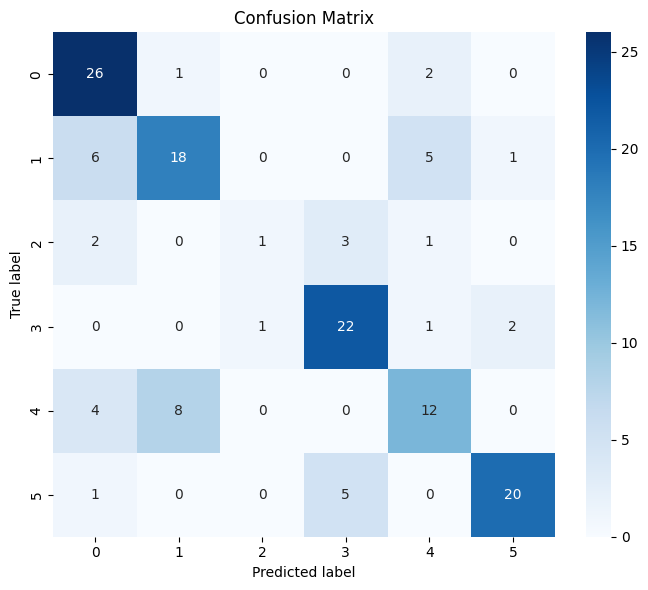

In [19]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = model(Xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)

acc = accuracy_score(y_true, y_pred)
f1m = f1_score(y_true, y_pred, average="macro")

print("=== TEST ===")
print("Accuracy:", round(acc, 4))
print("F1 macro:", round(f1m, 4))
print("\nClassification report:\n", classification_report(y_true, y_pred))


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(n_classes),
    yticklabels=range(n_classes)
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
